# 04 - LOPO Cross Validation
Leave-One-Participant-Out is an evaluation technique where a model is trained on all data points except one, which is used to test the model. This process is repeated for every single data point in the dataset (N times), and the performance metrics are averaged across all iterations. Train on 20, test on 1, repeat 21 times, average results.

How It Works:

If a dataset has N observations:

1. Iterate: For each data point \(i\), isolate it as the single validation/test set.
2. Train: Train the model on the remaining \(N-1\) observations.
3. Test: Evaluate the model’s prediction against the single left-out data point
4. Aggregate: Average the error scores (e.g., Mean Squared Error) across all \(N\) models.

Advantages:

1. Virtually zero bias: Since the model is trained on almost the entire dataset (N-1), the training sets closely mirror the full dataset distribution.
2. No randomness: Eliminates the variance caused by random train-test splits; the evaluation is entirely deterministic.
3. Maximum data utilization: Ideal for extremely small datasets where you cannot afford to hold out a large validation set.

Disadvantages:

1. High computational cost: Requires training and evaluating the model N times, which becomes highly expensive for large datasets.
2. High variance: Because test sets consist of just a single observation, an outlier or highly volatile data point can skew the final error estimate.

# Imports and Setup

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from sklearn.model_selection import LeaveOneGroupOut

import shutil

import sys
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
import scripts.feature_importance as fi

sns.set_theme(style='whitegrid')
RESULTS = Path('../results/lopo_cv')
RESULTS.mkdir(exist_ok=True)

print('All imports OK.')

c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


# Load Data and Define Features


In [2]:
with open('../data/features/features_512_511.pkl', 'rb') as f:
    df = pickle.load(f)

FEATURES = [
    'ipas', 'lhipas', 'fixation_nums', 'fixation_durations',
    'blink_rate', 'saccade_speeds', 'saccade_peak_speeds'
]

print('Dataset shape:', df.shape)
print('Total participants:', df['participant'].nunique())
print('Windows per participant:')
print(df['participant'].value_counts().sort_index().to_string())

Dataset shape: (347196, 18)
Total participants: 21
Windows per participant:
participant
p1     16534
p10    16357
p11    16394
p12    16611
p13    16517
p14    16542
p15    16628
p16    16601
p17    16367
p18    16580
p19    16608
p20    16442
p21    16584
p22    16607
p3     16543
p4     16615
p5     16399
p6     16577
p7     16496
p8     16574
p9     16620


# Models

In [3]:
def get_models():

    return {

        "SVM": LinearSVC(
            C=1.0,
            max_iter=3000,
            random_state=42
        ),

        "Logistic Regression": LogisticRegression(
            max_iter=5000,
            class_weight='balanced', 
            n_jobs=-1,
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=11,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=200,
            random_state=42,
            eval_metric="logloss",
            verbosity=0,
            n_jobs=-1
        )
    }

# LOPO Function

In [4]:
def run_lopo_task(
        X,
        y,
        groups,
        task_name):

    logo = LeaveOneGroupOut()

    results = []

    all_confusion_matrices = {}

    for model_name, model in get_models().items():

        print(f"\nRunning {task_name} | {model_name}")

        fold_accuracies = []
        fold_precisions = []
        fold_recalls = []
        fold_f1s = []

        overall_y_true = []
        overall_y_pred = []

        fold_counter = 1

        for train_idx, test_idx in logo.split(
                X,
                y,
                groups):

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            scaler = StandardScaler()

            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)

            preds = model.predict(X_test)

            fold_accuracies.append(
                accuracy_score(y_test, preds)
            )

            fold_precisions.append(
                precision_score(
                    y_test,
                    preds,
                    average="binary"
                )
            )

            fold_recalls.append(
                recall_score(
                    y_test,
                    preds,
                    average="binary"
                )
            )

            fold_f1s.append(
                f1_score(
                    y_test,
                    preds,
                    average="binary"
                )
            )

            overall_y_true.extend(y_test)
            overall_y_pred.extend(preds)

            fold_counter += 1

        cm = confusion_matrix(
            overall_y_true,
            overall_y_pred
        )

        all_confusion_matrices[model_name] = cm

        results.append({
            "Task": task_name,
            "Model": model_name,
            "Accuracy": np.mean(fold_accuracies),
            "Precision": np.mean(fold_precisions),
            "Recall": np.mean(fold_recalls),
            "F1": np.mean(fold_f1s),
            "Accuracy_STD": np.std(fold_accuracies)
        })

    return (
        pd.DataFrame(results),
        all_confusion_matrices
    )

In [ ]:


def run_lopo_task_with_fi(X, y, groups, task_name):
 
    logo = LeaveOneGroupOut()
 
    results = []
 
    all_confusion_matrices = {}
 
    feature_importance_storage = {
        "SVM": [],
        "Logistic Regression": [],
        "Random Forest": [],
        "KNN": [],
        "XGBoost": []
    }
 
    trained_models = {}
 
    for model_name, model in get_models().items():
 
        print(f"\nRunning {task_name} | {model_name}")
 
        fold_accuracies = []
        fold_precisions = []
        fold_recalls = []
        fold_f1s = []
 
        overall_y_true = []
        overall_y_pred = []
 
        for train_idx, test_idx in logo.split(X, y, groups):
 
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
 
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]
 
            scaler = StandardScaler()
 
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
 
            model.fit(X_train, y_train)
 
            # ==========================
            # Feature Importance
            # ==========================
            # save_outputs=False: only computes the importance numbers for
            # this fold. Nothing is written to disk here - that happens
            # once below, after averaging across all folds.
            imp_df = fi.generate_fold_fi_for_lopo(
                model_name,
                model,
                X_test,
                y_test,
                FEATURES,
                RESULTS / "temp_fi",
                save_outputs=False
            )
 
            feature_importance_storage[model_name].append(
                imp_df[["Feature", "Importance"]]
            )
 
            trained_models[model_name] = model
 
            # ==========================
 
            preds = model.predict(X_test)
 
            fold_accuracies.append(accuracy_score(y_test, preds))
            fold_precisions.append(
                precision_score(y_test, preds, average="binary")
            )
            fold_recalls.append(
                recall_score(y_test, preds, average="binary")
            )
            fold_f1s.append(f1_score(y_test, preds, average="binary"))
 
            overall_y_true.extend(y_test)
            overall_y_pred.extend(preds)
 
        cm = confusion_matrix(overall_y_true, overall_y_pred)
        all_confusion_matrices[model_name] = cm
 
        results.append({
            "Task": task_name,
            "Model": model_name,
            "Accuracy": np.mean(fold_accuracies),
            "Precision": np.mean(fold_precisions),
            "Recall": np.mean(fold_recalls),
            "F1": np.mean(fold_f1s),
            "Accuracy_STD": np.std(fold_accuracies)
        })
 
        # ======================================
        # Average feature importance across folds
        # ======================================
 
        fold_dfs = feature_importance_storage[model_name]
        merged = pd.concat(fold_dfs)
 
        avg_importance = (
            merged
            .groupby("Feature")["Importance"]
            .agg(["mean", "std"])
            .reset_index()
            .sort_values("mean", ascending=False)
        )

        out_dir = RESULTS / "task2_feature_importance"
        out_dir.mkdir(parents=True, exist_ok=True)
 
        avg_importance.to_csv(
            out_dir / f"{task_name}_{model_name}_LOPO_feature_importance.csv",
            index=False
        )
 
        plt.figure(figsize=(8, 5))
 
        sns.barplot(
            data=avg_importance,
            x="mean",
            y="Feature"
        )
 
        plt.title(
            f"{task_name} | {model_name}\nAverage Feature Importance Across LOPO Folds"
        )
 
        plt.xlabel("Mean Feature Importance")
 
        plt.tight_layout()
 
        plt.savefig(
            out_dir / f"{task_name}_{model_name}_LOPO_feature_importance.png",
            dpi=300
        )
 
        plt.close()
 
        folder_path = RESULTS / "temp_fi"
 
        try:
            shutil.rmtree(folder_path)
        except FileNotFoundError:
            pass
        except PermissionError:
            print("Permission denied deleting temp_fi.")
 
    return pd.DataFrame(results), all_confusion_matrices

# Sanity Checks

In [6]:
print("Participants:",
      df["participant"].nunique())

print(
    df["participant"]
      .value_counts()
      .sort_index()
)

Participants: 21
participant
p1     16534
p10    16357
p11    16394
p12    16611
p13    16517
p14    16542
p15    16628
p16    16601
p17    16367
p18    16580
p19    16608
p20    16442
p21    16584
p22    16607
p3     16543
p4     16615
p5     16399
p6     16577
p7     16496
p8     16574
p9     16620
Name: count, dtype: int64


# Task 1: Rest vs Load

In [7]:
task1_df = df.copy()

X_task1 = task1_df[FEATURES]

y_task1 = task1_df["load_detection_label"]

groups_task1 = task1_df["participant"]

task1_results, task1_cms = run_lopo_task(
    X_task1,
    y_task1,
    groups_task1,
    "Rest vs Load"
)


Running Rest vs Load | SVM

Running Rest vs Load | Logistic Regression


c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no ef


Running Rest vs Load | Random Forest

Running Rest vs Load | KNN

Running Rest vs Load | XGBoost


# Task 2: WM vs VA
Remove rest.

In [8]:
task2_df = df[df["label"] != 0].copy()
print("Data type:", task2_df["load_type_label"].dtype)
print("Unique values:", task2_df["load_type_label"].unique()[:10])
print("Missing values count:", task2_df["load_type_label"].isna().sum())

Data type: object
Unique values: [0 1]
Missing values count: 0


In [9]:
%load_ext autoreload
%autoreload 2

In [10]:
#task2_df = df[df["label"] != 0].copy()

X_task2 = task2_df[FEATURES]

y_task2 = task2_df["load_type_label"].astype(int)

groups_task2 = task2_df["participant"]

task2_results, task2_cms = run_lopo_task_with_fi(
    X_task2,
    y_task2,
    groups_task2,
    "WM vs VA"
)


Running WM vs VA | SVM

Running WM vs VA | Logistic Regression


c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no ef


Running WM vs VA | Random Forest

Running WM vs VA | KNN

Running WM vs VA | XGBoost


# Combine Results

In [15]:
results_df = pd.concat(
    [task1_results, task2_results],
    ignore_index=True
)

results_df

,Task,Model,Accuracy,Precision,Recall,F1,Accuracy_STD
0,Rest vs Load,SVM,0.994711,0.997726,0.996639,0.997130,0.012500
1,Rest vs Load,Logistic Regression,0.993628,0.999214,0.993956,0.996475,0.018479
2,Rest vs Load,Random Forest,0.987490,0.992680,0.994145,0.993302,0.020365
3,Rest vs Load,KNN,0.990959,0.995721,0.994663,0.995108,0.017132
4,Rest vs Load,XGBoost,0.989344,0.995242,0.993463,0.994242,0.019196
5,WM vs VA,SVM,0.750937,0.747062,0.823032,0.753981,0.125534
6,WM vs VA,Logistic Regression,0.757274,0.755221,0.820357,0.758661,0.118020
7,WM vs VA,Random Forest,0.746888,0.747702,0.807823,0.759692,0.108801
8,WM vs VA,KNN,0.692384,0.700369,0.725551,0.700062,0.098299
9,WM vs VA,XGBoost,0.736580,0.750766,0.777588,0.744836,0.108862


# Save Results

In [12]:
results_df.to_csv(
    RESULTS / "lopo_results.csv",
    index=False
)

print("Saved lopo_results.csv")

Saved lopo_results.csv


# Plot Confusion Matrices- Rest vs Load

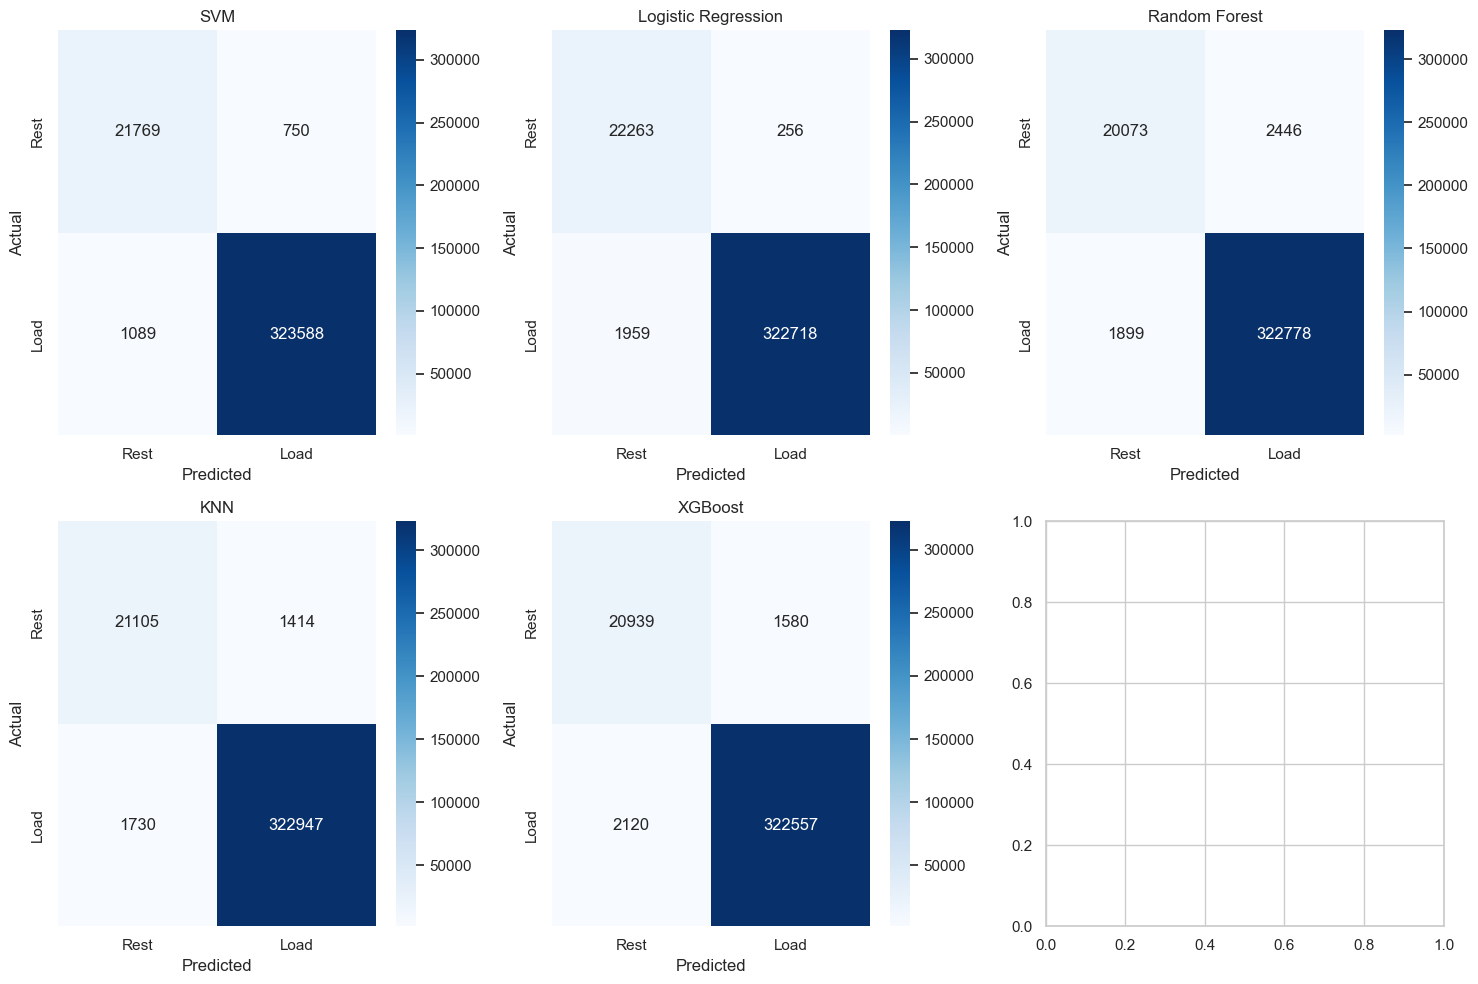

In [13]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,10)
)

axes = axes.flatten()

class_labels = ['Rest', 'Load']

for idx, (model_name, cm) in enumerate(task1_cms.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    axes[idx].set_title(model_name)

    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    RESULTS /
    "lopo_confusion_matrix_rest_vs_load.png",
    dpi=300
)

plt.show()

# Plot Confusion Matrices- WM vs VA

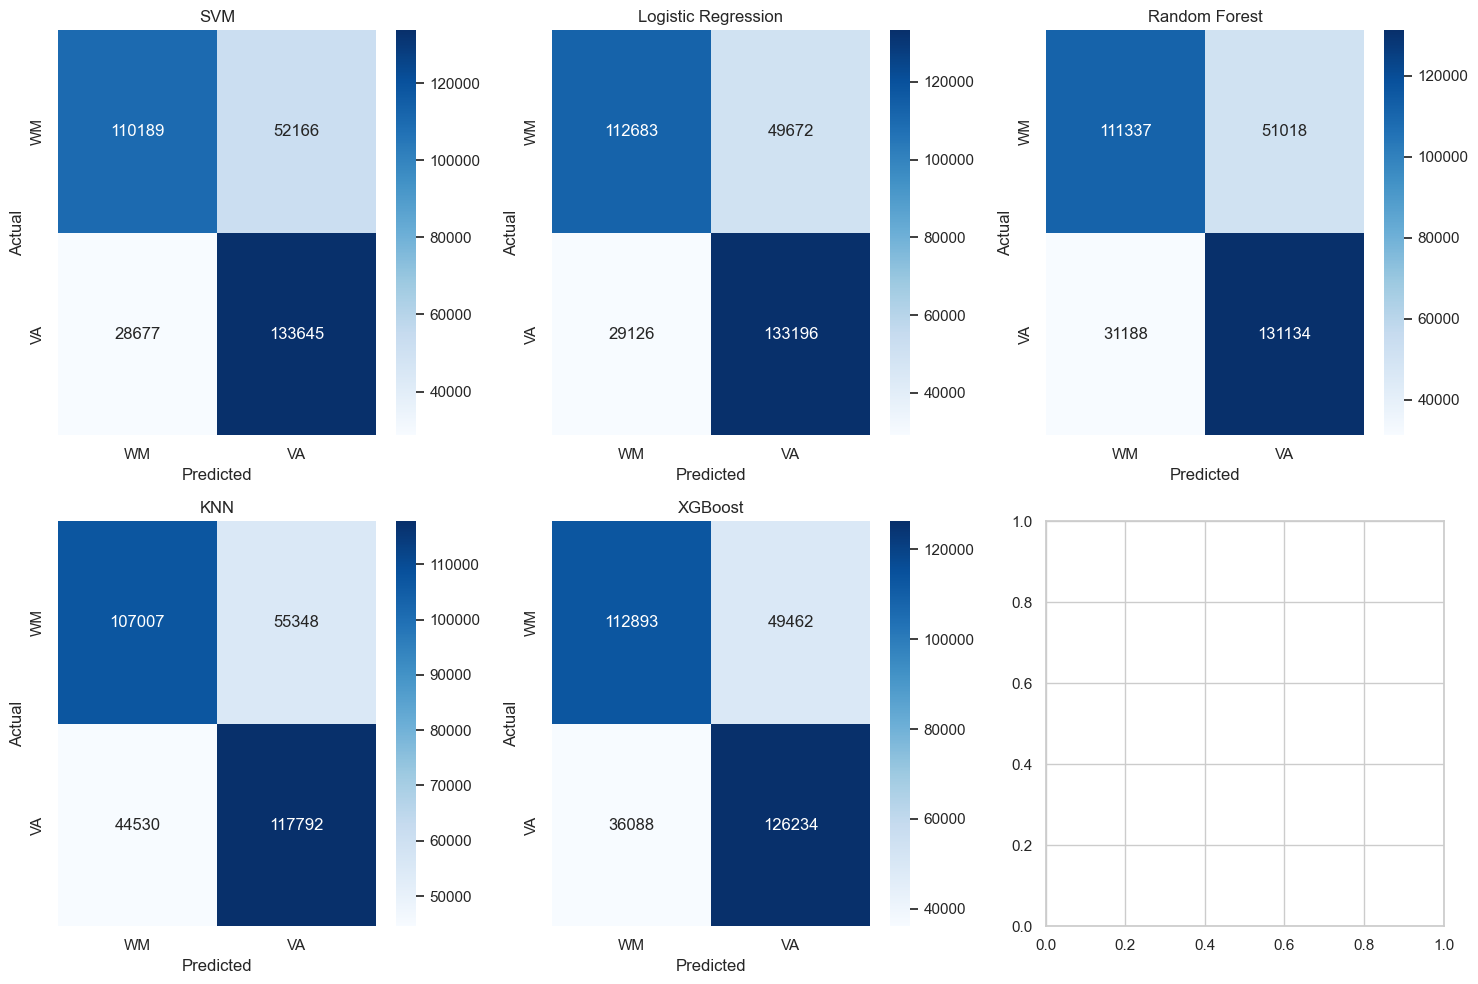

In [14]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,10)
)

axes = axes.flatten()

class_labels = ['WM', 'VA']

for idx, (model_name, cm) in enumerate(task2_cms.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    axes[idx].set_title(model_name)

    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    RESULTS /
    "lopo_confusion_matrix_wm_vs_va.png",
    dpi=300
)

plt.show()

# Feature Importance and Model Interpretability (VA vs WM)

* SHAP (SHapley Additive exPlanations): for tree based classifiers (Random Forest, XGBoost)
* Model Coefficients: For Linear Models (Logistic Regression & SVM)
* Permutation Feature Importance: For Distance-Based Models (KNN)